# Week 6

In [1]:
import jax
jax.config.update("jax_enable_x64", True) 

ROOM_SLUG, TAG  = "room_001", "30min"  

# --- Covariates entering the transition -------------------------------------------
USE_OFF_DAY     = True     # weekend / Danish public holiday flag


# --- Calendar cycles (0 drops the block entirely) ---------------------------------
N_DAILY_CYCLES  = [1, 4]     # -> sin_tod_1..k  / cos_tod_1..k
N_WEEKLY_CYCLES = [1]     # -> sin_week_1..k / cos_week_1..k



# --- Model / evaluation -----------------------------------------------------------
STATES          = 4
AR_LAGS         = 1 
ORDER           = 2     # Markov order of the higher-order transition
HORIZON_HOURS   = 6     # forecast horizon

FROZEN  = None #{"mu0": False} 

# ==================================================================================




In [2]:

from pathlib import Path

import pandas as pd
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from src.api.v4 import (
    HMM, 
    GaussEmission, 
    AutoregressiveGaussEmission,
    DynamicTransition, 
    MultivariateGaussEmission, 
    MultivariateAutoregressiveGaussEmission, 
    AIC, 
    BIC

)
from src.base.utils import transition_matrix_to_logits
from drivers.utils import (
    WEATHER_COLS, build_covariates, harmonic_range, standardise, state_means,
    load_base_data_path, load_train_data, load_val_data,
    plot_hmm_diagnostics, write_latex_table,
    rolling_forecast, rolling_persistence, rmse, mape, r2_score,load_y_df
)

## Load the series and build the design matrix

The prepared `y_train` / `y_val` arrays are one contiguous, gap-free, regularly spaced segment
(`longest_gap_free_segment` guarantees it), so the timestamps are recovered exactly from
`metadata.csv`'s start plus the bin width. Covariates are then built from those timestamps and
standardised on training rows only.

In [ ]:
data_dir = Path(load_base_data_path()) / ROOM_SLUG / TAG
meta     = pd.read_csv(data_dir / "metadata.csv").iloc[0]

room_name    = meta["room_name"]
BIN          = meta["bin"]
BIN_SECONDS  = int(pd.Timedelta(BIN).total_seconds())


print(f"Loaded {ROOM_SLUG}/{TAG} — {room_name} ({BIN}) with {BIN_SECONDS} seconds per bin")
BASELINE_PPM = float(meta["baseline_ppm"])

ys_train_df = load_y_df(ROOM_SLUG, TAG, "train")  # the driver's X_*.csv are not used:
ys_val_df   = load_y_df(ROOM_SLUG, TAG, "val")

ys_train_co2, ys_train_h = jnp.asarray(ys_train_df["co2"].to_numpy()), jnp.asarray(ys_train_df["humidity"].to_numpy())
ys_val_co2,   ys_val_h   = jnp.asarray(ys_val_df["co2"].to_numpy()), jnp.asarray(ys_val_df["humidity"].to_numpy())

TRAIN_IDX = len(ys_train_co2) #+ len(ys_val_co2)  # the index of the first validation bin
TEST_LEN = len(ys_val_co2)  # the number of validation bins
dates     = pd.date_range(meta["start"], periods=len(ys_train_co2) + len(ys_val_co2), freq=BIN)

X_raw, covariate_cols = build_covariates(
    dates,
    tod_harmonics=harmonic_range(N_DAILY_CYCLES),
    week_harmonics=harmonic_range(N_WEEKLY_CYCLES),
    use_off_day=USE_OFF_DAY,
    weather_cols=[],
)


X_std, x_mean, x_std = standardise(X_raw, TRAIN_IDX)
X_std       = jnp.asarray(X_std)
X_train_std = X_std[:TRAIN_IDX]
X_val_std   = X_std[TRAIN_IDX:]

num_covariates = X_std.shape[1]
init_dist      = jnp.full(STATES, 1.0 / STATES)

print(f"{room_name} ({ROOM_SLUG}/{TAG}) — {BIN} bins, min = {BASELINE_PPM:.0f} ppm")
print(f"  {TRAIN_IDX} train + {len(ys_val_co2)} validation bins, "
      f"{dates[0]} -> {dates[-1]}")
print(f"  {num_covariates} covariates: {', '.join(covariate_cols) or '(none)'}")

Loaded room_001/30min — Room 001 (30min) with 1800 seconds per bin
Room 001 (room_001/30min) — 30min bins, min = 400 ppm
  2752 train + 636 validation bins, 2023-11-13 04:00:00 -> 2024-01-22 17:30:00
  7 covariates: off_day, sin_week_1, cos_week_1, sin_tod_1, cos_tod_1, sin_tod_4, cos_tod_4


## Fit univariate models


In [4]:
models = {}

FIT_TOL = 1e-2
ys_train = ys_train_co2

FIT_KW  = dict(ys=ys_train, ts=None, xs=X_train_std, tol=FIT_TOL, frozen=FROZEN)

mu_seed    = jnp.quantile(ys_train, jnp.linspace(0.05, 0.95, STATES)).at[0].set(450)

sigma_seed = jnp.std(ys_train) * jnp.ones(STATES)

tm_seed    = jnp.full((STATES, STATES), 0.1).at[jnp.diag_indices(STATES)].set(0.7)

beta_init  = jnp.zeros((num_covariates, STATES, STATES - 1))

# --- 1. Gaussian emission + covariate transition -----------------------------------
print("=== Gaussian HMM + covariates ===")
gauss_cov = HMM(
    emission=GaussEmission.from_params(mu_seed, sigma_seed),
    transition=DynamicTransition(transition_matrix_to_logits(tm_seed), beta_init),
    inital_distribution=init_dist,
)
gauss_cov.fit(**FIT_KW)

print(f"  log-likelihood: {gauss_cov.log_likelihood():.4f}   converged: {gauss_cov.hmm_results.convergence}")
models["gauss_cov"] = gauss_cov



# --- 2. Autoregressive emission, warm-started from the Gaussian fit -----------------
print("=== Autoregressive HMM + covariates ===")
ar_cov = HMM(
    emission=AutoregressiveGaussEmission.from_params(
        state_means(gauss_cov.emission, ys_train),
        jnp.exp(gauss_cov.emission.log_sigma),
        jnp.zeros((AR_LAGS, STATES)),
    ),
    transition=DynamicTransition(gauss_cov.transition.transition_logits, gauss_cov.transition.beta),
    inital_distribution=init_dist,
)
ar_cov.fit(**FIT_KW)
print(f"  log-likelihood: {ar_cov.log_likelihood():.4f}   converged: {ar_cov.hmm_results.convergence}")
print(f"  phi (per state): {np.asarray(ar_cov.emission.phi())}")

models["ar_cov"] = ar_cov




=== Gaussian HMM + covariates ===
  log-likelihood: -16040.0231   converged: True
=== Autoregressive HMM + covariates ===
  log-likelihood: -13186.0446   converged: True
  phi (per state): [[0.15632905 0.96473847 0.93611287 0.86795657]]


In [5]:
#from joblib import Parallel, delayed
#
#mu0_range = jnp.linspace(400, 500, 10)  # Range of mu0 values to profile
#
#def fit_one(mu0, ys, xs, ts, sigma_seed, tm_seed, beta_init, init_dist):
#    mu_seed = jnp.quantile(ys_train, jnp.linspace(0.05, 0.95, STATES)).at[0].set(mu0)
#    model = HMM(
#        emission=GaussEmission.from_params(mu_seed, sigma_seed),
#        transition=DynamicTransition(transition_matrix_to_logits(tm_seed), beta_init),
#        inital_distribution=init_dist,
#    )
#    model.fit(ys=ys, xs=xs, ts=ts, frozen={"mu0": False})
#    return float(model.emission.mu0), float(model.ll_fits[-1])
#
#mu0_list = []
#ll_list = []
#
#for mu0 in mu0_range:
#    print(f"Fitting model with mu0={mu0:.2f}...")
#    mu0_fit, ll_fit = fit_one(mu0, ys_train, X_train_std, None, sigma_seed, tm_seed, beta_init, init_dist)
#    mu0_list.append(mu0_fit)
#    ll_list.append(ll_fit)
#
#

In [6]:
#lls = jnp.array(ll_list)
#like = jnp.exp(lls- jnp.max(lls))  # Normalize for numerical stability
#
#plt.figure(figsize=(8, 5))
#plt.plot(mu0_range, like, label="Profile Likelihood", color="blue")
##plt.axvline(x=gauss_cov.emission.mu[0], color="red", linestyle="--", label="Estimated $\mu_0$")
#plt.title("Profile Likelihood of $\mu_0$")
#plt.xlabel("$\mu_0$ (ppm)")
#plt.ylabel("Normalized Likelihood")
#plt.legend()

## Residual and state diagnostics

Pseudo-residual diagnostics per model, then the decoded (most likely filtered) state over the
training block.

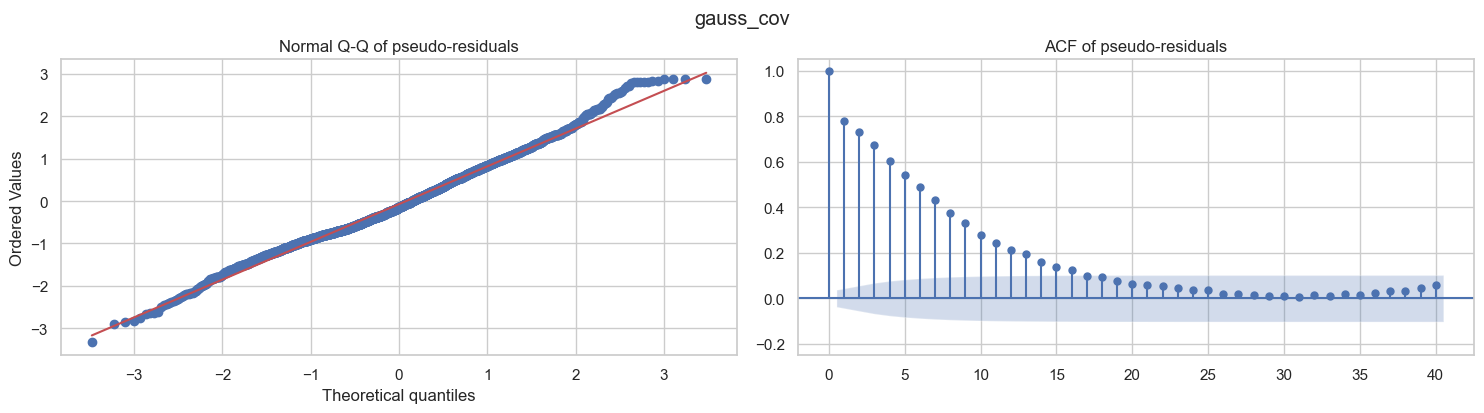

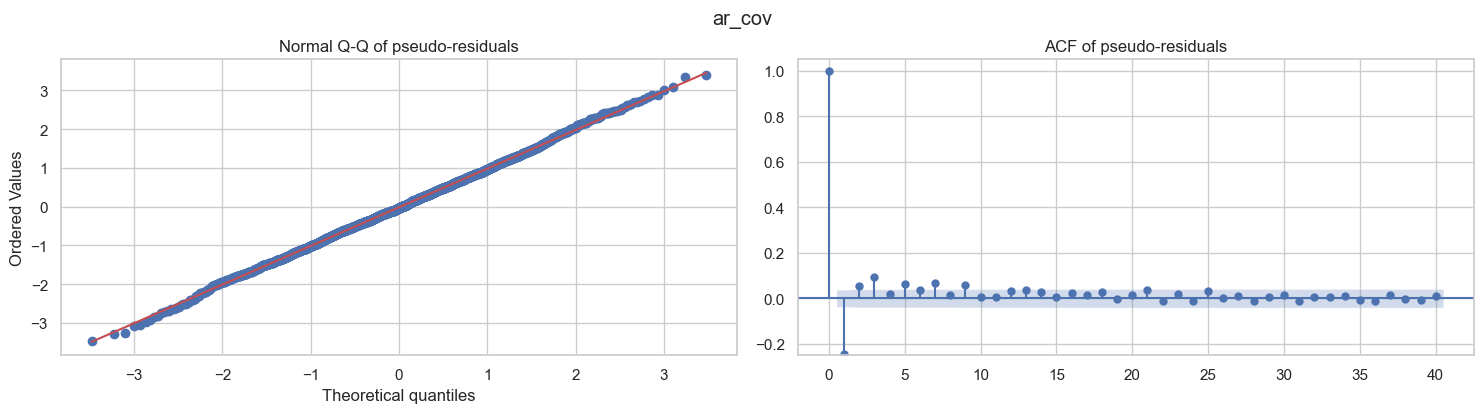

In [7]:
for name, m in models.items():
    fig = plot_hmm_diagnostics(m)
    fig.suptitle(name, y=1.03)
    plt.show()

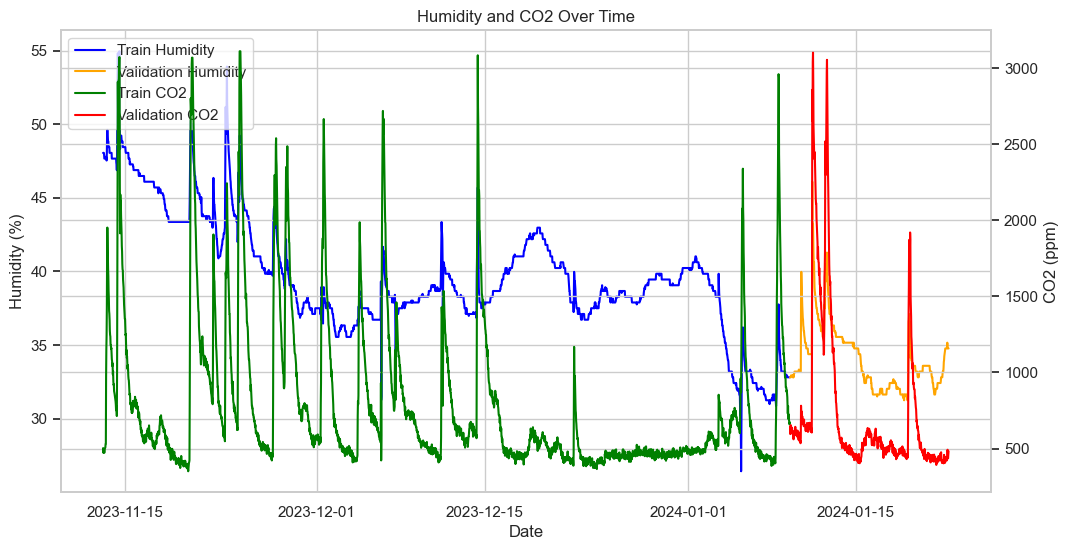

In [8]:
#plotting ys_train_h over time  and co 2 as secondday axis
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(dates[:TRAIN_IDX], ys_train_h, label="Train Humidity", color="blue")
ax1.plot(dates[TRAIN_IDX:TRAIN_IDX + TEST_LEN], ys_val_h, label="Validation Humidity", color="orange")
ax1.set_xlabel("Date")
ax1.set_ylabel("Humidity (%)")
ax2 = ax1.twinx()
ax2.plot(dates[:TRAIN_IDX], ys_train_co2, label="Train CO2", color="green")
ax2.plot(dates[TRAIN_IDX:TRAIN_IDX + TEST_LEN], ys_val_co2, label="Validation CO2", color="red")
ax2.set_ylabel("CO2 (ppm)")
plt.title("Humidity and CO2 Over Time")
# combine legends from both axes into one
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")
plt.show()

### Fit multivariate models

In [9]:
ys_train = jnp.vstack((ys_train_co2, ys_train_h)).T

FIT_KW  = dict(ys=ys_train, ts=None, xs=X_train_std, tol=FIT_TOL, frozen=FROZEN)


mu_seed    = jnp.quantile(ys_train, jnp.linspace(0.05, 0.95,  STATES), axis=0).T

sigma_seed = jnp.std(ys_train, axis=0)[:, None] * jnp.ones((2, STATES))

tm_seed    = jnp.full((STATES, STATES), 0.1).at[jnp.diag_indices(STATES)].set(0.7)

beta_init  = jnp.zeros((num_covariates, STATES, STATES - 1))




In [ ]:

multi_models = {}
# --- 1. Gaussian emission + covariate transition -----------------------------------
print("=== Gaussian HMM + covariates ===")
multi_gauss_cov = HMM(
    emission=MultivariateGaussEmission.from_params(mu_seed, sigma_seed),
    transition=DynamicTransition(transition_matrix_to_logits(tm_seed), beta_init),
    inital_distribution=init_dist,
)
multi_gauss_cov.fit(**FIT_KW)

print(f"  log-likelihood: {multi_gauss_cov.log_likelihood():.4f}   converged: {multi_gauss_cov.hmm_results.convergence}")
multi_models["multi_gauss_cov"] = multi_gauss_cov



# --- 2. Autoregressive emission, warm-started from the Gaussian fit -----------------
print("=== Autoregressive HMM + covariates ===")
multi_ar_cov = HMM(
    emission=MultivariateAutoregressiveGaussEmission.from_params(
        state_means(multi_gauss_cov.emission, ys_train),
        jnp.exp(multi_gauss_cov.emission.log_sigma),
        jnp.zeros((2,AR_LAGS, STATES)),
    ),
    transition=DynamicTransition(gauss_cov.transition.transition_logits, gauss_cov.transition.beta),
    inital_distribution=init_dist,
)
multi_ar_cov.fit(**FIT_KW)
print(f"  log-likelihood: {multi_ar_cov.log_likelihood():.4f}   converged: {multi_ar_cov.hmm_results.convergence}")
print(f"  phi (per state): {np.asarray(multi_ar_cov.emission.phi())}")

multi_models["multi_ar_cov"] = multi_ar_cov

=== Gaussian HMM + covariates ===
  log-likelihood: -23606.4285   converged: True
=== Autoregressive HMM + covariates ===
  log-likelihood: -11750.3506   converged: True
  phi (per state): [[[ 9.97840840e-01  9.89359658e-01  9.98584023e-01  9.97528227e-01]]

 [[-3.03450621e-02  7.52722753e-03 -8.47879235e-04 -3.54314799e-03]]]


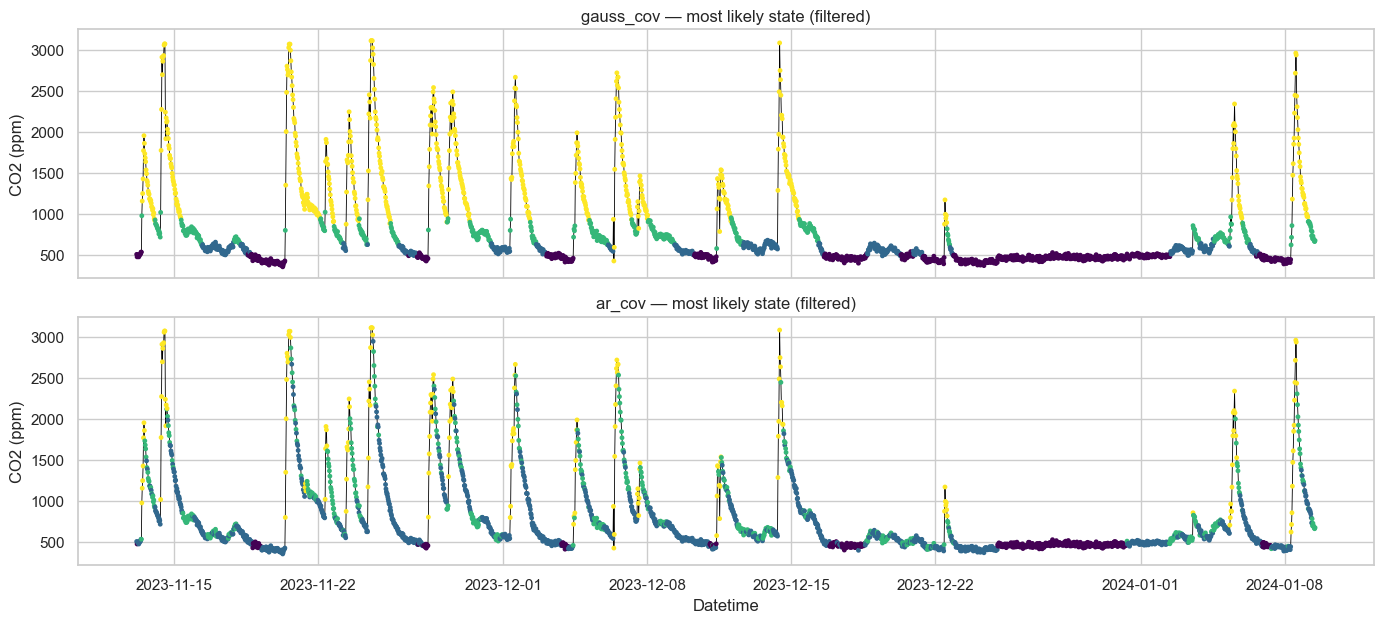

In [11]:
fig, axes = plt.subplots(len(models), 1, figsize=(14, 3.2 * len(models)), sharex=True)

for ax, (name, m) in zip(np.atleast_1d(axes), models.items()):
    utt = np.asarray(m.state_results.utt).reshape(len(ys_train_co2), -1)
    # Augmented index i has current base state i % STATES, so the second-order model
    # shares one colour scale with the first-order ones.
    decoded = utt.argmax(axis=1) % STATES
    ax.plot(dates[:TRAIN_IDX], np.asarray(ys_train_co2), color="black", lw=0.6, zorder=1)
    ax.scatter(dates[:TRAIN_IDX], np.asarray(ys_train_co2), c=decoded, cmap="viridis", s=6, zorder=2)
    ax.set(title=f"{name} — most likely state (filtered)", ylabel="CO2 (ppm)")
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
plt.tight_layout(); plt.show()

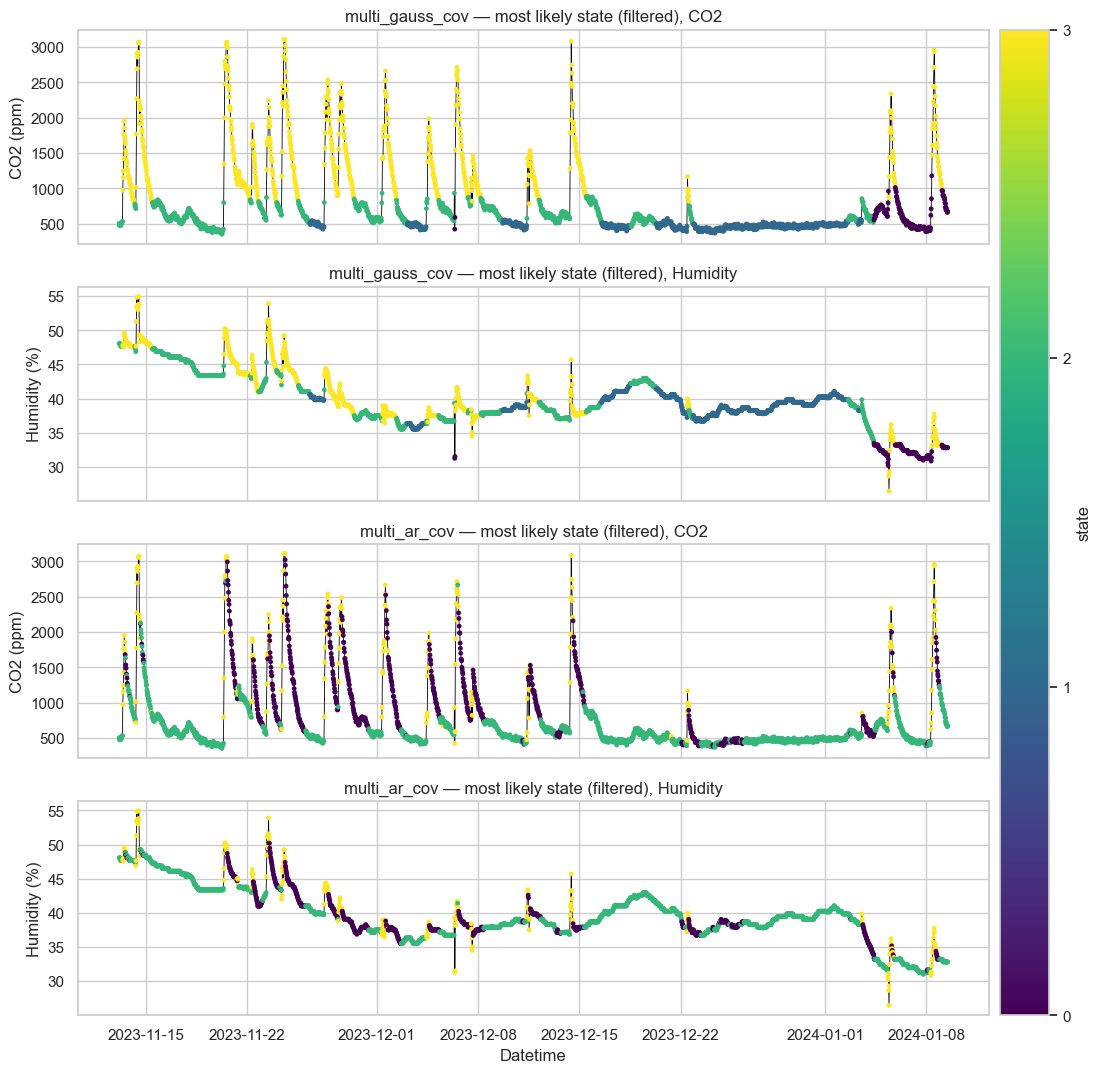

In [12]:
# One joint state sequence per model, drawn on both observed series: the state is decoded
# once from the filtered distribution (which conditions on CO2 and humidity together), then
# coloured onto each series so the two panels of a model share the same state labels.
series = [("CO2 (ppm)", np.asarray(ys_train_co2)), ("Humidity (%)", np.asarray(ys_train_h))]
n_rows = len(multi_models) * len(series)
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3.2 * n_rows), sharex=True)
axes = np.atleast_1d(axes).reshape(len(multi_models), len(series))

for row, (name, m) in zip(axes, multi_models.items()):
    utt = np.asarray(m.state_results.utt).reshape(TRAIN_IDX, -1)
    decoded = utt.argmax(axis=1) % STATES
    for ax, (label, y) in zip(row, series):
        ax.plot(dates[:TRAIN_IDX], y, color="black", lw=0.6, zorder=1)
        sc = ax.scatter(dates[:TRAIN_IDX], y, c=decoded, cmap="viridis",
                        vmin=0, vmax=STATES - 1, s=6, zorder=2)
        ax.set(title=f"{name} — most likely state (filtered), {label.split()[0]}", ylabel=label)
fig.colorbar(sc, ax=axes.ravel().tolist(), ticks=range(STATES), label="state", pad=0.01)
axes[-1, -1].set_xlabel("Datetime")
plt.show()

In [25]:
## Comparing models 

print("=== Model comparison ===")
print(f"Mu vals for Gaussian HMM + covariates: {np.asarray(gauss_cov.emission.mu(0,0))}")
print(f"Mu vals for Multivariate Gaussuan HMM + covariates: {np.asarray(multi_gauss_cov.emission.mu(0,0))}") 

mu_vals = np.asarray(multi_gauss_cov.emission.mu(0,0)[0, :]) 
std = np.asarray(multi_gauss_cov.emission.sigma(0,0))[0, :]
emission = GaussEmission.from_params(mu_vals, std)
transition = multi_gauss_cov.transition 

hmm = HMM(emission=emission, transition=transition, inital_distribution=init_dist) 

models["Gauss_cov_from_multi"] = hmm

=== Model comparison ===
Mu vals for Gaussian HMM + covariates: [ 457.20711618  570.3927112   770.5064643  1566.89864811]
Mu vals for Multivariate Gaussuan HMM + covariates: [[ 450.99078286  466.61975949  636.3437083  1520.77182592]
 [  32.23302528   39.00010295   40.51929564   41.74976763]]


## Rolling forecasts on the validation block

A fixed `HORIZON_HOURS`-ahead forecast anchored at *every* validation observation, against a
persistence baseline. The filtered state distribution at the anchor is propagated forward
through the covariate-driven transition matrices, and the emission mean is taken under the
resulting state distribution; for the autoregressive models each prediction is fed back in as
the next step's lag. Anchors stop `K` steps before the end of the block so every target lies
inside validation and nothing is scored against the training block.

In [26]:
K = int(round(HORIZON_HOURS * 3600 / BIN_SECONDS))

print(f"Horizon: {HORIZON_HOURS} h = {K} steps")
ys = jnp.asarray(ys_train_co2.tolist() + ys_val_co2.tolist()) 

start, end = TRAIN_IDX, len(ys)
forecasts = {"Persistence baseline": rolling_persistence(ys, start, end, K)}
for name, m in models.items():
    forecasts[name] = rolling_forecast(m, ys, X_std, start, end, K)

pred_table = pd.DataFrame([
    {"Model": name, "RMSE": rmse(yt, yp), "MAPE%": mape(yt, yp), "R2": r2_score(yt, yp), "n": len(yt)}
    for name, (idx, yt, yp, _sp) in forecasts.items()
]).sort_values("RMSE").reset_index(drop=True)

pred_table.round(3)

Horizon: 6 h = 12 steps


,Model,RMSE,MAPE%,R2,n
0,gauss_cov,403.897,23.157,0.427,624
1,Gauss_cov_from_multi,410.666,24.177,0.408,624
2,ar_cov,427.839,30.058,0.358,624
3,Persistence baseline,438.007,16.865,0.327,624


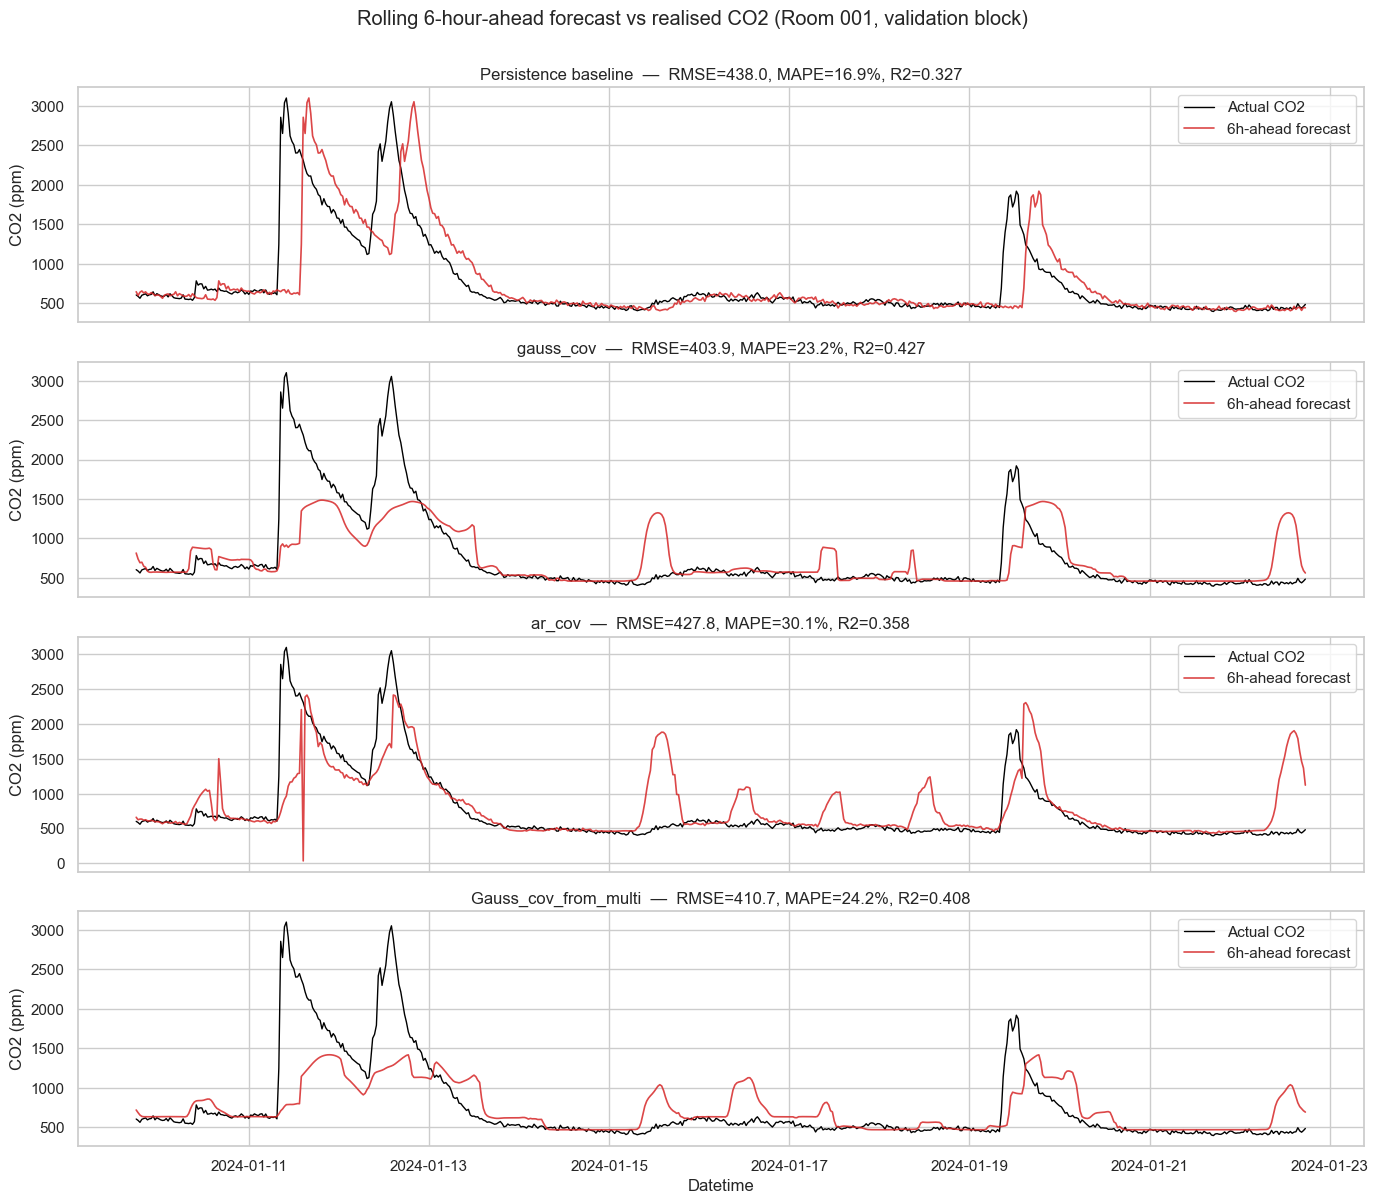

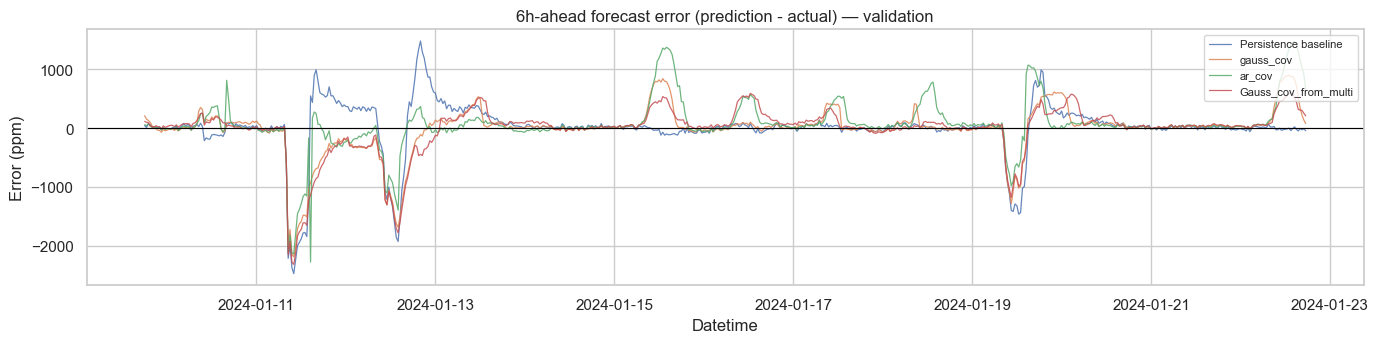

In [27]:
# --- forecast vs realised, one panel per model -------------------------------------
fig, axes = plt.subplots(len(forecasts), 1, figsize=(14, 3 * len(forecasts)), sharex=True)
for ax, (name, (idx, yt, yp, _sp)) in zip(np.atleast_1d(axes), forecasts.items()):
    ax.plot(dates[idx], yt, color="black", lw=1.0, label="Actual CO2")
    ax.plot(dates[idx], yp, color="tab:red", lw=1.2, alpha=0.85,
            label=f"{HORIZON_HOURS}h-ahead forecast")
    ax.set(title=f"{name}  —  RMSE={rmse(yt, yp):.1f}, MAPE={mape(yt, yp):.1f}%, "
                 f"R2={r2_score(yt, yp):.3f}", ylabel="CO2 (ppm)")
    ax.legend(loc="upper right")
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
fig.suptitle(f"Rolling {HORIZON_HOURS}-hour-ahead forecast vs realised CO2 "
             f"({room_name}, validation block)", y=1.002)
plt.tight_layout(); plt.show()

# --- forecast error, all models on one axis ----------------------------------------
fig, ax = plt.subplots(figsize=(14, 3.6))
for name, (idx, yt, yp, _sp) in forecasts.items():
    ax.plot(dates[idx], yp - yt, lw=0.9, alpha=0.85, label=name)
ax.axhline(0.0, color="black", lw=0.8)
ax.set(title=f"{HORIZON_HOURS}h-ahead forecast error (prediction - actual) — validation",
       ylabel="Error (ppm)", xlabel="Datetime")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()